In [1]:
import pandas as pd
import numpy as np
from wavelets1 import GridWaveletTransform, Morlet, Cauchy
import matplotlib.pyplot as plt

In [2]:
duration = 100; sampleRate = 50; N = duration*sampleRate; T = 1/sampleRate
samples = np.linspace(0, duration, N, endpoint=False)
signals = np.zeros((5, samples.shape[0]))

"Import ambient magnetic field signal."
df=pd.read_csv(r'Swarm_MAGA_HR_20150317_0900.csv', sep=',',header=None)
r = df[10]
swarm = np.array([np.fromstring(r[i][1:-1], dtype=float, sep=' ') for i in range(1, r.shape[0])]).T[:,160000:160000+N]
data =swarm[0]

C:\Users\aphoffm2\AppData\Local\Temp\1\ipykernel_22200\2232759324.py:6: DtypeWarning: Columns (2,5,6,8,9) have mixed types. Specify dtype option on import or set low_memory=False.
  df=pd.read_csv(r'Swarm_MAGA_HR_20150317_0900.csv', sep=',',header=None)


Reconstruction error: 1.2089056396016923e-07


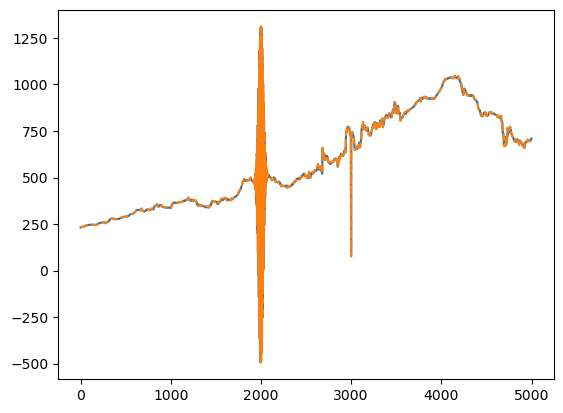

In [3]:
# Create a sample time-series: a sine wave for demonstration
sample_rate = 50.0          # 50 Hz sampling rate
num_samples = 5000          # 5000 samples
t = np.arange(num_samples) / sample_rate
time = t - np.mean(t)
cauchy_waveform = 1000*Cauchy(alpha=900).eval_analysis(10*(time+10))
morlet_waveform = 1000*Morlet().eval_analysis(50*(time-10))
data+=morlet_waveform.real + cauchy_waveform.real

# Initialize the GridWaveletTransform
transform = GridWaveletTransform(
    data=data,
    fs = sample_rate,
)

# Perform forward wavelet transform
coefficients = transform.forward()

# Perform inverse wavelet transform (reconstruction)
reconstructed = transform.inverse(coefficients)

# Calculate and print reconstruction error
reconstruction_error = np.linalg.norm(reconstructed - data)
print(f"Reconstruction error: {reconstruction_error}")

# Optional: Plot grid decimation pattern
#transform.plot_grid_decimation()

# Optional: Plot scalogram
#transform.plot_scalogram(coefficients)
plt.plot(reconstructed)
plt.plot(data, linestyle='--')

# Optional: Compute frame bounds
#A, B = transform.compute_frame_bounds()
#print(f"Frame bounds: A = {A}, B = {B}, Ratio B/A = {B/A}")


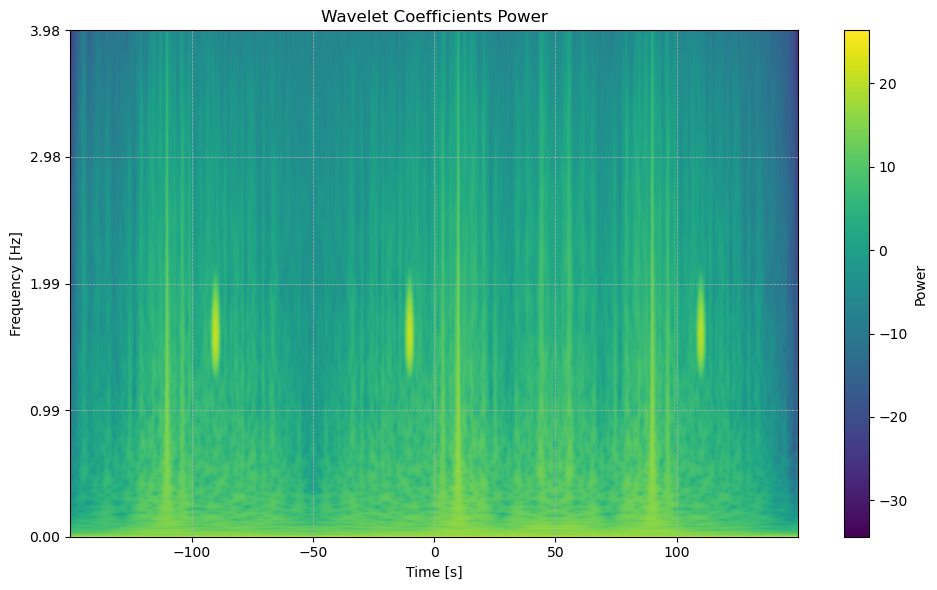

In [4]:
transform.plot_coeff_power(coefficients)

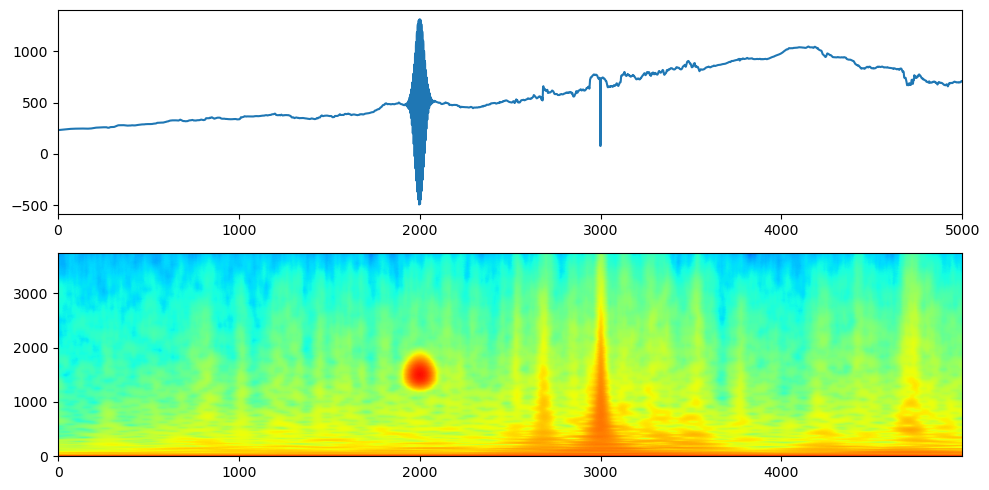

In [5]:
fig, ax = plt.subplots(2, 1, figsize=(10, 5))
ax[0].plot(reconstructed, label='Original data')
#ax[0].axvline(x=transform.pad_width, color='r', linestyle='--')
#ax[0].axvline(x=num_samples+transform.pad_width, color='r', linestyle='--')
#ax[0].axvline(x=transform.pad_width+num_samples//2, color='black')
ax[0].set_xlim(0, num_samples)

ax[1].imshow(np.log(np.abs(coefficients[:,transform.pad_width:-transform.pad_width])), aspect='auto', cmap='jet', origin='lower')
#ax[1].axvline(x=transform.pad_width, color='r', linestyle='--')
#ax[1].axvline(x=transform.pad_width+num_samples//2, color='black')
#ax[1].axvline(x=num_samples+transform.pad_width, color='r', linestyle='--')
plt.tight_layout()

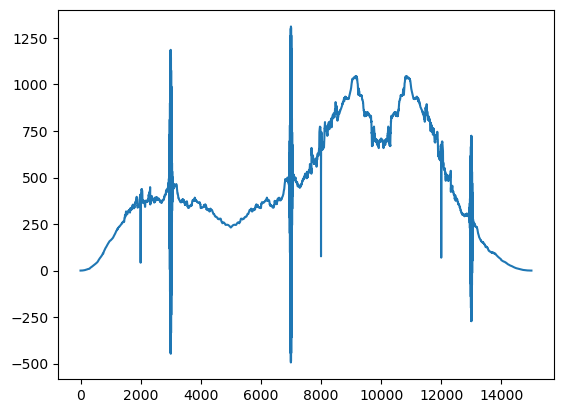

In [6]:
plt.plot(transform.data)

Reconstruction error: 3.5068373096480476


c:\Users\aphoffm2\AppData\Local\anaconda3\Lib\site-packages\matplotlib\cbook.py:1699: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
c:\Users\aphoffm2\AppData\Local\anaconda3\Lib\site-packages\matplotlib\cbook.py:1345: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


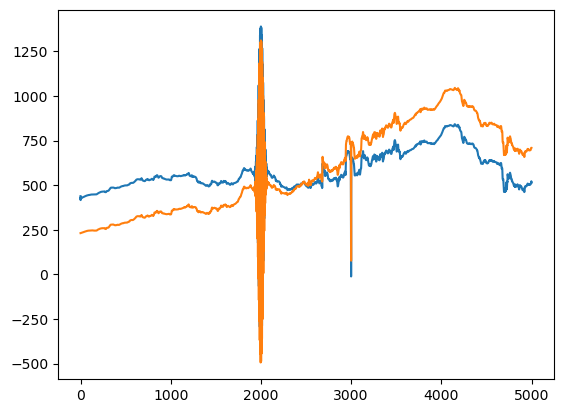

In [7]:
from wavelets import WaveletAnalysis as WA
w1 = WA(data, dt=T, dj=1/8, frequency=True, unbias=False, mask_coi = True)
wn1 = w1.wavelet_transform.real
W_n = wn1 
Y_00 = w1.wavelet.time(0)
s = w1.scales
r_sum = np.sum(W_n.real.T / s ** .5, axis=-1).T
amb_mf = r_sum * (1/8 * T ** .5 / (w1.C_d * Y_00))
amb_mf += w1.data.mean(axis=w1.axis, keepdims=True)
plt.plot(amb_mf)
plt.plot(swarm[0])
print("Reconstruction error:", np.sqrt(np.mean(data[100:-100] - amb_mf[100:-100].real)**2))

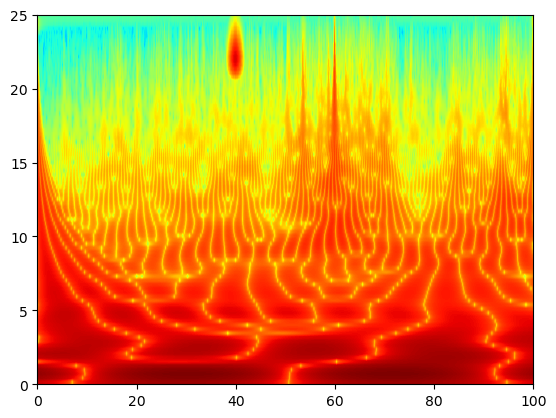

In [8]:
plt.imshow(np.log(np.abs(wn1)+1e-6), aspect='auto', extent=[0, duration, 0, 1/(2*T)], cmap='jet')